In [1]:
# 02_optuna_tuning
#
# 목적: 01단계 베이스라인(valid AUC 0.942) 대비 하이퍼파라미터를 Optuna로 탐색해 개선한다.
#
# 원칙: 튜닝 전 과정에서 test셋은 절대 사용하지 않는다. 모든 trial은 train으로 학습하고
#      valid AUC로만 평가/선택한다. 최적 파라미터를 찾은 뒤 최종 모델을 train으로 재학습하고,
#      test는 이 노트북의 마지막에 딱 한 번만 사용해 최종 성능을 보고한다.
#
# 입력: data/processed/model_table_final.csv
# 출력: models/lightgbm_final.txt, models/best_params.json

In [2]:
import json
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, log_loss, average_precision_score,
    precision_recall_curve, precision_recall_fscore_support, confusion_matrix,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
SERIES_1 = "#2a78d6"

CATEGORICAL_COLS = ["city", "registered_via", "gender"]
DROP_COLS = ["msno", "snapshot", "split", "is_churn"]

# 1시간 타임아웃에도 완주 못 할 만큼 트라이얼당 시간이 오래 걸려서(풀 train 1.37M행 x 최대 2000라운드)
# 탐색 단계는 train을 일부 샘플링해서 빠르게 돌리고, 최종 모델만 전체 train으로 재학습하는 방식으로 변경.
N_TRIALS = 25
TUNE_SAMPLE_SIZE = 300_000
TUNE_NUM_BOOST_ROUND = 800
TUNE_STOPPING_ROUNDS = 30

In [3]:
df = pd.read_csv(PROCESSED_DIR / "model_table_final.csv")
for c in CATEGORICAL_COLS:
    df[c] = df[c].astype("category")

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]
test_df = df[df["split"] == "test"]

X_train, y_train = train_df[FEATURE_COLS], train_df["is_churn"]
X_valid, y_valid = valid_df[FEATURE_COLS], valid_df["is_churn"]
X_test, y_test = test_df[FEATURE_COLS], test_df["is_churn"]

# 탐색용 서브샘플 (stratified, train 안에서만) - 최종 재학습은 전체 X_train 사용
pos = train_df[train_df["is_churn"] == 1]
neg = train_df[train_df["is_churn"] == 0]
pos_n = int(TUNE_SAMPLE_SIZE * len(pos) / len(train_df))
neg_n = int(TUNE_SAMPLE_SIZE * len(neg) / len(train_df))
tune_train_df = pd.concat([
    pos.sample(n=pos_n, random_state=42),
    neg.sample(n=neg_n, random_state=42),
])
X_tune, y_tune = tune_train_df[FEATURE_COLS], tune_train_df["is_churn"]
print(f"탐색용 샘플: {len(tune_train_df):,}행 (이탈률 {y_tune.mean() * 100:.2f}%)")

tune_train_set = lgb.Dataset(X_tune, label=y_tune, categorical_feature=CATEGORICAL_COLS)
tune_valid_set = lgb.Dataset(X_valid, label=y_valid, categorical_feature=CATEGORICAL_COLS, reference=tune_train_set)

full_train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
full_valid_set = lgb.Dataset(X_valid, label=y_valid, categorical_feature=CATEGORICAL_COLS, reference=full_train_set)

print(f"train {len(train_df):,} / valid {len(valid_df):,} / test {len(test_df):,}")

탐색용 샘플: 299,999행 (이탈률 6.39%)
train 695,051 / valid 148,940 / test 148,940


In [4]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "seed": 42,
        "verbose": -1,
        # trial마다 min_child_samples(=min_data_in_leaf)가 바뀌는데 Dataset을 재사용하므로
        # feature_pre_filter를 꺼서 LightGBM이 이전 trial의 필터링 결과를 캐시하지 않게 한다.
        "feature_pre_filter": False,
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
    }

    model = lgb.train(
        params,
        tune_train_set,
        num_boost_round=TUNE_NUM_BOOST_ROUND,
        valid_sets=[tune_valid_set],
        valid_names=["valid"],
        callbacks=[lgb.early_stopping(stopping_rounds=TUNE_STOPPING_ROUNDS, first_metric_only=True, verbose=False)],
    )

    valid_pred = model.predict(X_valid, num_iteration=model.best_iteration)
    return roc_auc_score(y_valid, valid_pred)


BASELINE_VALID_AUC = 0.9896  # 01_lightgbm_baseline.ipynb 결과 (train_v2 제거 후 재학습)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"베이스라인 valid AUC: {BASELINE_VALID_AUC:.4f}")
print(f"Optuna 최고 valid AUC(샘플 기준): {study.best_value:.4f}")
print("best params:")
print(json.dumps(study.best_params, indent=2))

  0%|          | 0/25 [00:00<?, ?it/s]

베이스라인 valid AUC: 0.9896
Optuna 최고 valid AUC(샘플 기준): 0.9894
best params:
{
  "num_leaves": 236,
  "max_depth": 11,
  "learning_rate": 0.01598387174722713,
  "min_child_samples": 28,
  "feature_fraction": 0.8724506684766818,
  "bagging_fraction": 0.8933899425966071,
  "bagging_freq": 9,
  "lambda_l1": 9.078375852198261e-07,
  "lambda_l2": 3.4339210234101867e-06
}


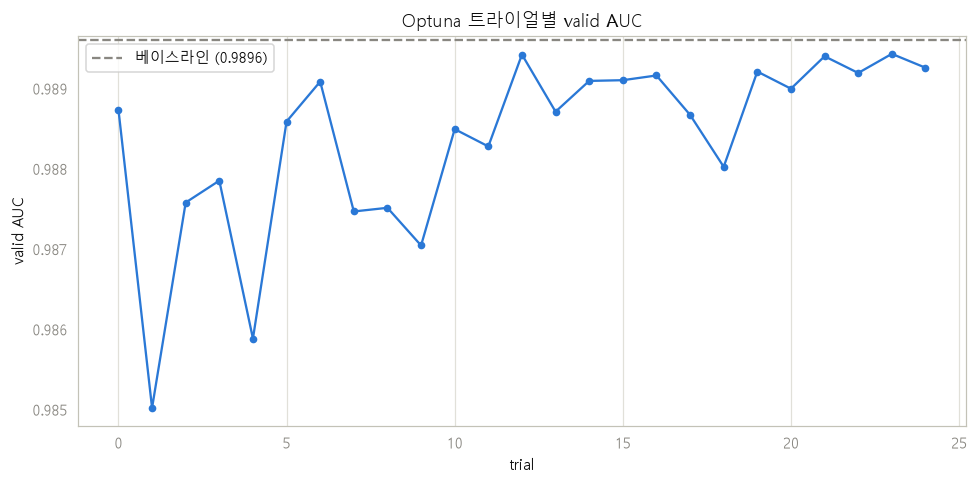

In [5]:
trials_df = study.trials_dataframe().sort_values("number")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(trials_df["number"], trials_df["value"], color=SERIES_1, marker="o", markersize=4, linewidth=1.5)
ax.axhline(BASELINE_VALID_AUC, color="#898781", linestyle="--", linewidth=1.5, label=f"베이스라인 ({BASELINE_VALID_AUC:.4f})")
ax.set_xlabel("trial")
ax.set_ylabel("valid AUC")
ax.set_title("Optuna 트라이얼별 valid AUC")
ax.legend()
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [6]:
# 최적 파라미터로 최종 모델 재학습 (전체 train으로, valid로 early stopping)
final_params = {
    "objective": "binary",
    "metric": "auc",
    "seed": 42,
    "verbose": -1,
    "feature_pre_filter": False,
    **study.best_params,
}

final_model = lgb.train(
    final_params,
    full_train_set,
    num_boost_round=3000,
    valid_sets=[full_valid_set],
    valid_names=["valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=100, first_metric_only=True), lgb.log_evaluation(period=100)],
)

print(f"final best iteration: {final_model.best_iteration}")

Training until validation scores don't improve for 100 rounds


[100]	valid's auc: 0.988299


[200]	valid's auc: 0.989364


[300]	valid's auc: 0.990275


[400]	valid's auc: 0.990558


...

[700]	valid's auc: 0.990904


[800]	valid's auc: 0.990913


[900]	valid's auc: 0.990921


Early stopping, best iteration is:
[815]	valid's auc: 0.990929
Evaluated only: auc


final best iteration: 815


In [7]:
# valid에서 F1 최적 threshold 결정 (test에는 절대 이 과정을 적용하지 않고, 여기서 정한 threshold를 그대로 재사용)
valid_pred = final_model.predict(X_valid, num_iteration=final_model.best_iteration)
precisions, recalls, thresholds = precision_recall_curve(y_valid, valid_pred)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_threshold = thresholds[f1_scores[:-1].argmax()]

print(f"[valid] AUC: {roc_auc_score(y_valid, valid_pred):.4f}")
print(f"[valid] 최적 threshold(F1 기준): {best_threshold:.4f}")

[valid] AUC: 0.9909
[valid] 최적 threshold(F1 기준): 0.3550


In [8]:
# ------------------------------------------------------------------
# test는 이 셀에서 딱 한 번만 사용한다 (튜닝/threshold 결정에는 전혀 관여하지 않았음)
# ------------------------------------------------------------------
test_pred = final_model.predict(X_test, num_iteration=final_model.best_iteration)
test_pred_label = (test_pred >= best_threshold).astype(int)

test_auc = roc_auc_score(y_test, test_pred)
test_logloss = log_loss(y_test, test_pred)
test_pr_auc = average_precision_score(y_test, test_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_pred_label, average="binary")

print("===== 최종 TEST 성능 =====")
print(f"AUC: {test_auc:.4f}  PR-AUC: {test_pr_auc:.4f}  LogLoss: {test_logloss:.4f}")
print(f"Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")
print()
cm = confusion_matrix(y_test, test_pred_label)
print("Confusion matrix (rows=actual, cols=predicted):")
print(cm)

===== 최종 TEST 성능 =====
AUC: 0.9915  PR-AUC: 0.9066  LogLoss: 0.0538
Precision: 0.7696  Recall: 0.8589  F1: 0.8118

Confusion matrix (rows=actual, cols=predicted):
[[136972   2448]
 [  1343   8177]]


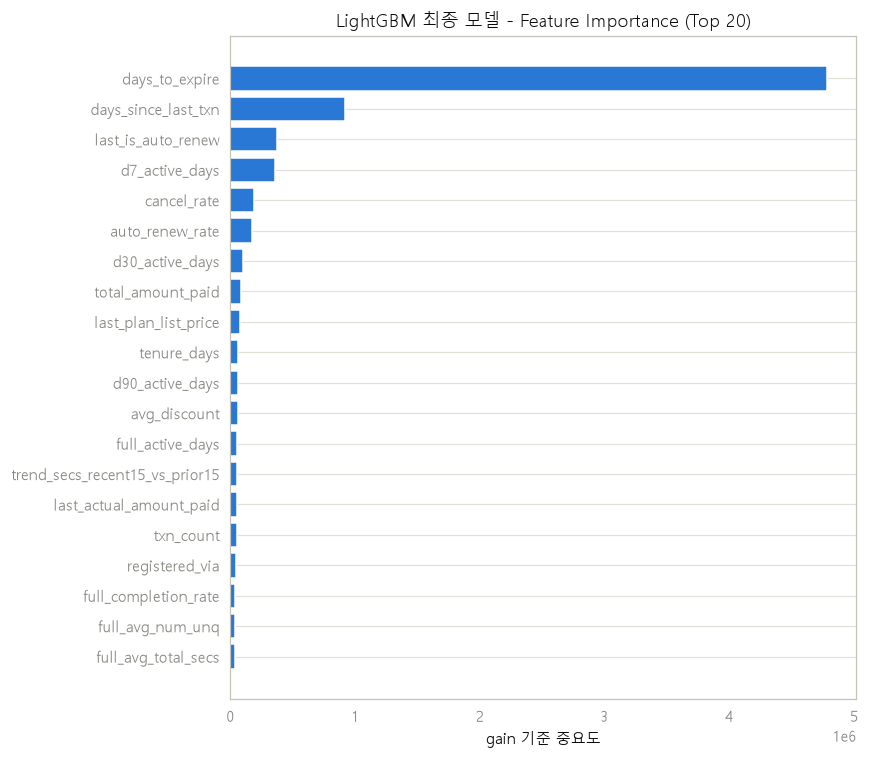

In [9]:
importance = pd.Series(final_model.feature_importance(importance_type="gain"), index=FEATURE_COLS)
importance = importance.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importance.index, importance.values, color=SERIES_1)
ax.set_xlabel("gain 기준 중요도")
ax.set_title("LightGBM 최종 모델 - Feature Importance (Top 20)")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [10]:
final_model.save_model(str(MODELS_DIR / "lightgbm_final.txt"))

with open(MODELS_DIR / "best_params.json", "w", encoding="utf-8") as f:
    json.dump({"params": study.best_params, "threshold": float(best_threshold)}, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {MODELS_DIR / 'lightgbm_final.txt'}")
print(f"저장 완료: {MODELS_DIR / 'best_params.json'}")

저장 완료: ..\models\lightgbm_final.txt
저장 완료: ..\models\best_params.json
